# project02 - Leveraged LP with multi-protocol margin readout

Builds on *project01* by adding **leverage** and a **lending policy**.
The same simulation result is then inspected through three different
protocol lenses (Arcadia, Aave, Moonwell) without changing the underlying
math - only the labels change.

In [1]:
from lp_analysis import (
    AssetPair, PriceRange, PoolConfig, LendingPolicy, StrategyConfig,
    simulate, linear_price_sweep, to_frame, dashboard,
    arcadia_view, aave_view, moonwell_view,
    margin_metrics, margin_path, liquidation_price_bounds,
    solve_liquidation_price, compute_pnl, compute_greeks, compute_exposure,
)
import matplotlib.pyplot as plt
import numpy as np

## 1. Strategy spec: ETH/USDC, 5x, USDC debt

In [2]:
pool = PoolConfig(
    pair=AssetPair('ETH', 'USDC'),
    price_initial=3500.0,
    price_range=PriceRange(3200.0, 3800.0),
)
lending = LendingPolicy(
    collateral_factors={'ETH': 0.80, 'USDC': 0.90},
    liquidation_factors={'ETH': 0.85, 'USDC': 0.95},
    borrow_apr_by_symbol={'USDC': 6.0, 'ETH': 2.0},
    lp_protocol_factor=0.95,
    minimum_margin_usd=0.0,
)
strategy = StrategyConfig(
    name='ETH/USDC 5x USDC-debt',
    pool=pool, lending=lending,
    capital_asset1=10_000.0, leverage=5.0, debt_symbol='USDC',
)

## 2. Simulate a 90-day price sweep

In [3]:
scenario = linear_price_sweep(strategy, n_points=600, days_elapsed=90.0)
result = simulate(strategy, scenario)
print(f'Initial debt:  {result.initial.debt_amount:,.2f} {result.initial.debt_token}')
print(f'Liquidity L  : {result.initial.liquidity:.3f}')
print(f'n steps      : {result.n_steps}')

Initial debt:  40,000.00 USDC
Liquidity L  : 10049.129
n steps      : 600


## 3. Single-strategy dashboard

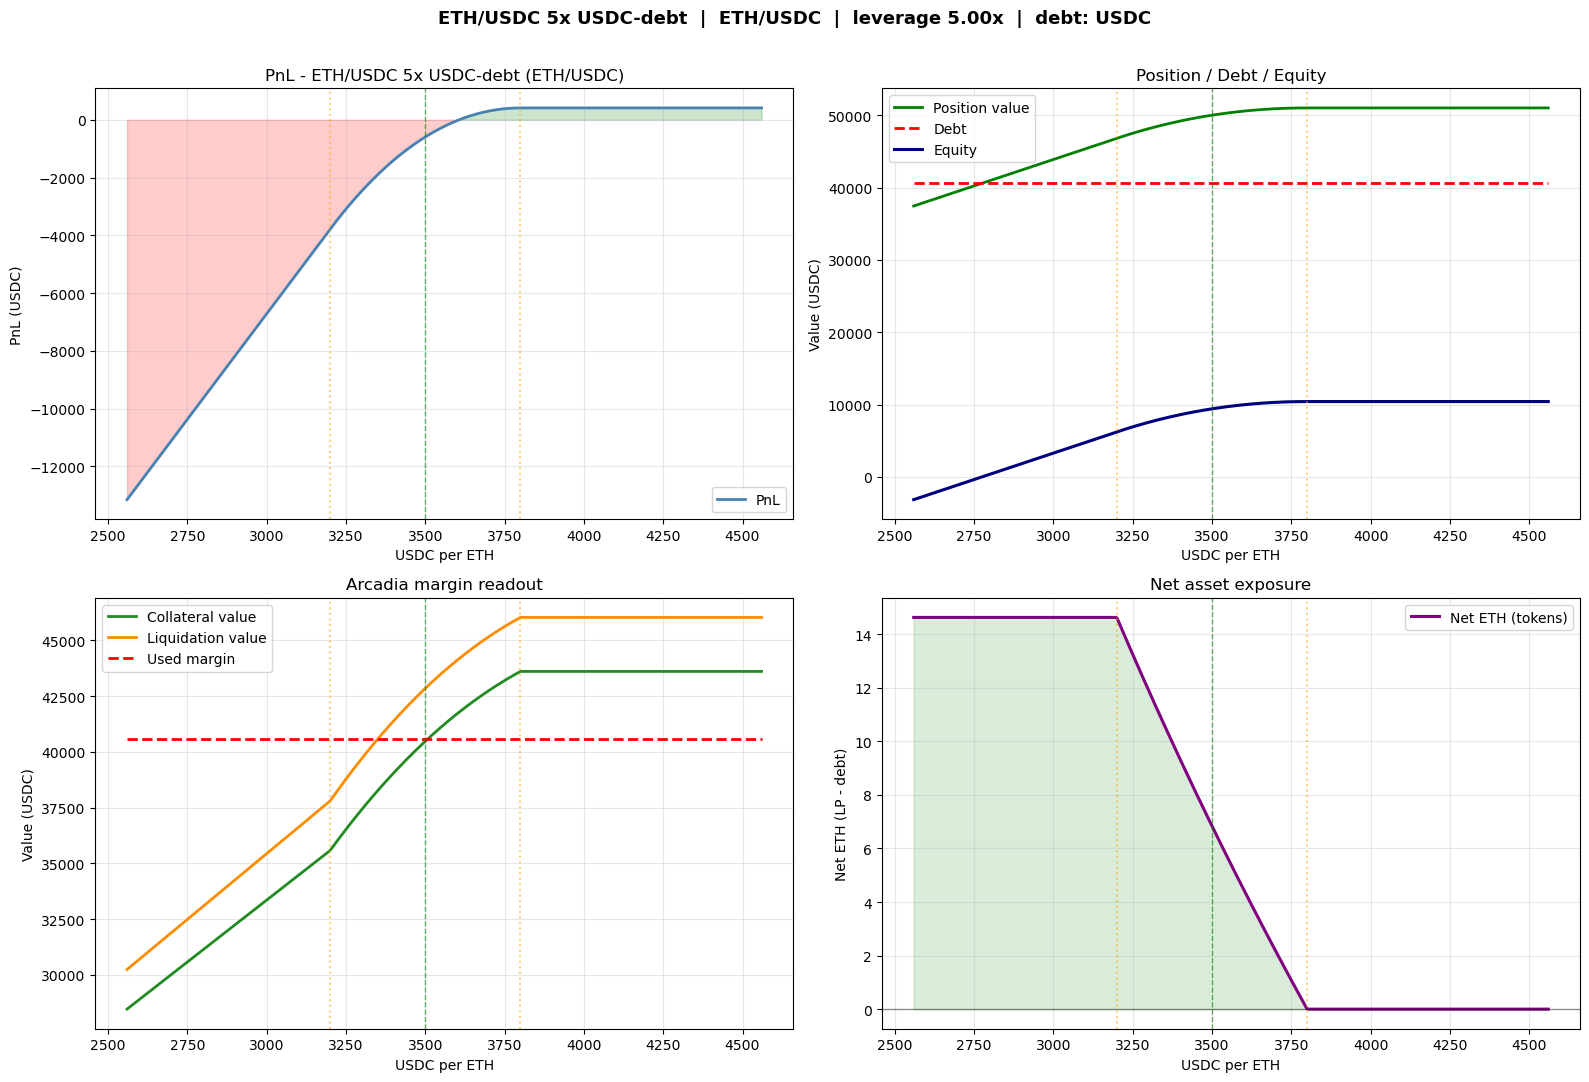

In [4]:
fig = dashboard(result)
plt.show()

## 4. Same numbers through three protocol lenses

Pick a representative step (near `price_initial`) and present the same
MarginMetrics object through Arcadia, Aave, and Moonwell vocabularies.

In [5]:
i0 = int(np.argmin(np.abs(scenario.price_path - pool.price_initial)))
rows = margin_path(result)
m_at_i0 = rows[i0]
print(f'== Step {i0}: price = {scenario.price_path[i0]:.2f} ==')
from lp_analysis.lending import MarginMetrics
m = MarginMetrics(
    spot_value=m_at_i0['spot_value'], open_position=m_at_i0['open_position'],
    minimum_margin=m_at_i0['minimum_margin'], used_margin=m_at_i0['used_margin'],
    collateral_value=m_at_i0['collateral_value'],
    liquidation_value=m_at_i0['liquidation_value'],
    free_margin=m_at_i0['free_margin'], state=m_at_i0['state'],
)
print('\nArcadia view :', arcadia_view(m))
print('\nAave view    :', aave_view(m))
print('\nMoonwell view:', moonwell_view(m))

== Step 282: price = 3501.57 ==

Arcadia view : {'spot_value': 50010.70854256027, 'open_position': 40596.18004671654, 'minimum_margin': 0.0, 'available_margin': 40495.53988331376, 'collateral_value': 40495.53988331376, 'liquidation_value': 42871.048539085365, 'used_margin': 40596.18004671654, 'free_margin': -100.64016340277885, 'health_ratio': 1.0560365159911842, 'state': 'unhealthy', 'is_liquidatable': False}

Aave view    : {'total_collateral': 50010.70854256027, 'total_debt': 40596.18004671654, 'ltv': 0.8117497477998786, 'health_factor': 1.0560365159911842, 'is_liquidatable': False}

Moonwell view: {'credit_limit': 40495.53988331376, 'borrowed': 40596.18004671654, 'credit_remaining': -100.64016340277885, 'credit_remaining_pct': -0.24852159939778395, 'is_liquidatable': False}


## 5. Liquidation price bounds

In [6]:
print('Within scenario sweep :', liquidation_price_bounds(result))
print('Solver (lower):', solve_liquidation_price(result, side='lower'))
print('Solver (upper):', solve_liquidation_price(result, side='upper'))

Within scenario sweep : {'lower': 2560.0, 'upper': 3351.318864774624}
Solver (lower): 3311.9112521249544
Solver (upper): None


## 6. Tidy polars frame

In [7]:
df = to_frame(result)
df.select(['step', 'price', 'amount_ETH', 'amount_USDC',
           'debt_amount', 'equity_asset1',
           'margin_used', 'margin_free', 'margin_state']).head(10)

step,price,amount_ETH,amount_USDC,debt_amount,equity_asset1,margin_used,margin_free,margin_state
i64,f64,f64,f64,f64,f64,f64,f64,str
0,2560.0,14.626782,0.0,40596.180047,-3151.617492,40596.180047,-12138.312505,"""liquidatable"""
1,2563.338898,14.626782,0.0,40596.180047,-3102.780156,40596.180047,-12101.196129,"""liquidatable"""
2,2566.677796,14.626782,0.0,40596.180047,-3053.942819,40596.180047,-12064.079754,"""liquidatable"""
3,2570.016694,14.626782,0.0,40596.180047,-3005.105483,40596.180047,-12026.963378,"""liquidatable"""
4,2573.355593,14.626782,0.0,40596.180047,-2956.268146,40596.180047,-11989.847002,"""liquidatable"""
5,2576.694491,14.626782,0.0,40596.180047,-2907.43081,40596.180047,-11952.730627,"""liquidatable"""
6,2580.033389,14.626782,0.0,40596.180047,-2858.593474,40596.180047,-11915.614251,"""liquidatable"""
7,2583.372287,14.626782,0.0,40596.180047,-2809.756137,40596.180047,-11878.497876,"""liquidatable"""
8,2586.711185,14.626782,0.0,40596.180047,-2760.918801,40596.180047,-11841.3815,"""liquidatable"""
